In [1]:
import json
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from thefuzz import fuzz

In [2]:
category_untuned = []
with open("category-gpt-4.1-mini-2025-04-14.jsonl") as file:
    for line in file:
        category_untuned.append(json.loads(line))

In [3]:
category_finetuned = []
with open("category-ft:gpt-4.1-mini-2025-04-14:u-chicago:cgfp-category-try1:CobZKZz1.jsonl") as file:
    for line in file:
        category_finetuned.append(json.loads(line))

In [4]:
tag_untuned = []
with open("tag-gpt-4.1-mini-2025-04-14.jsonl") as file:
    for line in file:
        tag_untuned.append(json.loads(line))

In [5]:
tag_finetuned = []
with open("tag-ft:gpt-4.1-mini-2025-04-14:u-chicago:cgfp-tag-try1:CobaLhVa.jsonl") as file:
    for line in file:
        tag_finetuned.append(json.loads(line))

In [6]:
def category_to_df(data):
    df_input = []
    df_category = []
    df_subcategory = []
    df_multiplicity = []
    df_inputfuzz = []
    df_good_category = []
    df_good_subcategory = []

    for pair in data:
        actual, expected = pair["actual"]["food_products"], pair["expected"]["food_products"]
        for index, row in enumerate(expected):
            df_input.append(row["input"])
            df_category.append(row["category"])
            df_subcategory.append(row.get("subcategory", ""))
            df_multiplicity.append(len(expected))
            df_inputfuzz.append(fuzz.ratio(row["input"], actual[index].get("input", "")) if index < len(actual) else 0)
            df_good_category.append(row["category"] == actual[index].get("category", "") if index < len(actual) else False)
            df_good_subcategory.append(row.get("subcategory", "") == actual[index].get("subcategory", "") if index < len(actual) else False)
    
    return pd.DataFrame({
        "input": df_input,
        "category": df_category,
        "subcategory": df_subcategory,
        "multiplicity": df_multiplicity,
        "inputfuzz": df_inputfuzz,
        "good_category": df_good_category,
        "good_subcategory": df_good_subcategory,
    })

df_category_untuned = category_to_df(category_untuned)
df_category_finetuned = category_to_df(category_finetuned)

In [7]:
def tag_to_df(data):
    df_input = []
    df_multiplicity = []
    df_basic_type = []
    df_sub_types = []
    df_flavored = []
    df_shape = []
    df_meat_cut = []
    df_meat_skin = []
    df_meat_bone = []
    df_seed_pitted = []
    df_processing = []
    df_cooked = []
    df_whole_grain = []
    df_sodium_level = []
    df_caffeine = []
    df_diet = []
    df_reduced_sugar = []
    df_sweetened = []
    df_additives = []
    df_accommodation = []
    df_frozen = []
    df_packaging = []
    df_commodity = []

    filled = Counter()
    
    for pair in data:
        actual, expected = pair["actual"]["food_products"], pair["expected"]["food_products"]
        for index, row in enumerate(expected):
            df_input.append(row["input"])
            df_multiplicity.append(len(expected))
            df_basic_type.append(row.get("basic_type", "") == actual[index].get("basic_type", "") if index < len(actual) else False)
            df_sub_types.append(row.get("sub_types", []) == actual[index].get("sub_types", []) if index < len(actual) else False)
            df_flavored.append(row.get("flavored", "") == actual[index].get("flavored", "") if index < len(actual) else False)
            df_shape.append(row.get("shape", "") == actual[index].get("shape", "") if index < len(actual) else False)
            df_meat_cut.append(row.get("meat_cut", "") == actual[index].get("meat_cut", "") if index < len(actual) else False)
            df_meat_skin.append(row.get("meat_skin", "") == actual[index].get("meat_skin", "") if index < len(actual) else False)
            df_meat_bone.append(row.get("meat_bone", "") == actual[index].get("meat_bone", "") if index < len(actual) else False)
            df_seed_pitted.append(row.get("seed_pitted", "") == actual[index].get("seed_pitted", "") if index < len(actual) else False)
            df_processing.append(row.get("processing", "") == actual[index].get("processing", "") if index < len(actual) else False)
            df_cooked.append(row.get("cooked", "") == actual[index].get("cooked", "") if index < len(actual) else False)
            df_whole_grain.append(row.get("whole_grain", "") == actual[index].get("whole_grain", "") if index < len(actual) else False)
            df_sodium_level.append(row.get("sodium_level", "") == actual[index].get("sodium_level", "") if index < len(actual) else False)
            df_caffeine.append(row.get("caffeine", "") == actual[index].get("caffeine", "") if index < len(actual) else False)
            df_diet.append(row.get("diet", "") == actual[index].get("diet", "") if index < len(actual) else False)
            df_reduced_sugar.append(row.get("reduced_sugar", "") == actual[index].get("reduced_sugar", "") if index < len(actual) else False)
            df_sweetened.append(row.get("sweetened", "") == actual[index].get("sweetened", "") if index < len(actual) else False)
            df_additives.append(row.get("additives", "") == actual[index].get("additives", "") if index < len(actual) else False)
            df_accommodation.append(row.get("accommodation", "") == actual[index].get("accommodation", "") if index < len(actual) else False)
            df_frozen.append(row.get("frozen", "") == actual[index].get("frozen", "") if index < len(actual) else False)
            df_packaging.append(row.get("packaging", "") == actual[index].get("packaging", "") if index < len(actual) else False)
            df_commodity.append(row.get("commodity", "") == actual[index].get("commodity", "") if index < len(actual) else False)
            for field in [
                "flavored", "shape", "meat_cut", "meat_skin", "meat_bone", "seed_pitted", "processing", "cooked", "whole_grain", "sodium_level",
                "caffeine", "diet", "reduced_sugar", "sweetened", "additives", "accommodation", "frozen", "packaging", "commodity",
            ]:
                filled[field] += int(row.get(field, "") != "")

    return pd.DataFrame({
        "input": df_input,
        "multiplicity": df_multiplicity,
        "basic_type": df_basic_type,
        "sub_types": df_sub_types,
        "flavored": df_flavored,
        "shape": df_shape,
        "meat_cut": df_meat_cut,
        "meat_skin": df_meat_skin,
        "meat_bone": df_meat_bone,
        "seed_pitted": df_seed_pitted,
        "processing": df_processing,
        "cooked": df_cooked,
        "whole_grain": df_whole_grain,
        "sodium_level": df_sodium_level,
        "caffeine": df_caffeine,
        "diet": df_diet,
        "reduced_sugar": df_reduced_sugar,
        "sweetened": df_sweetened,
        "additives": df_additives,
        "accommodation": df_accommodation,
        "frozen": df_frozen,
        "packaging": df_packaging,
        "commodity": df_commodity,
    }), filled

df_tag_untuned, filled_untuned = tag_to_df(tag_untuned)
df_tag_finetuned, filled_finetuned = tag_to_df(tag_finetuned)

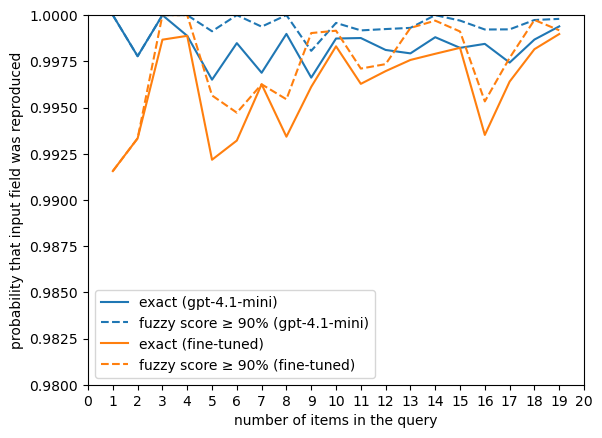

In [8]:
fig, ax = plt.subplots()

fraction100 = []
fraction90 = []
for multiplicity in range(1, 20):
    df_this_multiplicity = df_category_untuned.query(f"multiplicity == {multiplicity}")
    fraction100.append(np.count_nonzero(df_this_multiplicity["inputfuzz"] == 100) / len(df_this_multiplicity))
    fraction90.append(np.count_nonzero(df_this_multiplicity["inputfuzz"] >= 90) / len(df_this_multiplicity))
ax.plot(range(1, 20), fraction100, color="tab:blue", ls="-", label="exact (gpt-4.1-mini)")
ax.plot(range(1, 20), fraction90, color="tab:blue", ls="--", label="fuzzy score ≥ 90% (gpt-4.1-mini)")

fraction100 = []
fraction90 = []
for multiplicity in range(1, 20):
    df_this_multiplicity = df_category_finetuned.query(f"multiplicity == {multiplicity}")
    fraction100.append(np.count_nonzero(df_this_multiplicity["inputfuzz"] == 100) / len(df_this_multiplicity))
    fraction90.append(np.count_nonzero(df_this_multiplicity["inputfuzz"] >= 90) / len(df_this_multiplicity))
ax.plot(range(1, 20), fraction100, color="tab:orange", ls="-", label="exact (fine-tuned)")
ax.plot(range(1, 20), fraction90, color="tab:orange", ls="--", label="fuzzy score ≥ 90% (fine-tuned)")

ax.set_xlabel("number of items in the query")
ax.set_ylabel("probability that input field was reproduced")
ax.set_xlim(0, 20)
ax.set_xticks(range(21))
ax.set_ylim(0.98, 1)
ax.legend()

None

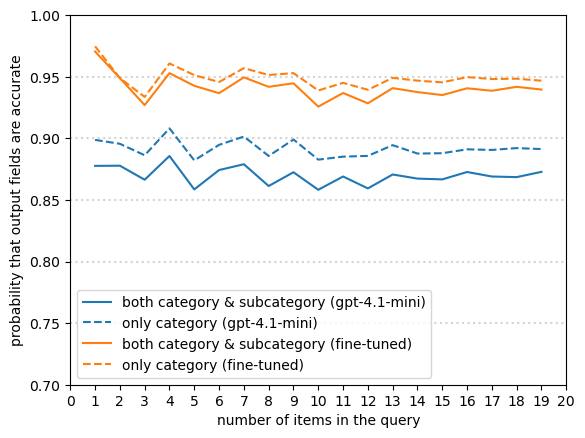

In [9]:
fig, ax = plt.subplots()

for level in np.arange(0.75, 1, 0.05):
    ax.axhline(level, color="lightgrey", ls=":")

fraction1 = []
fraction2 = []
for multiplicity in range(1, 20):
    df_this_multiplicity = df_category_untuned.query(f"multiplicity == {multiplicity}")
    fraction1.append(np.count_nonzero(df_this_multiplicity["good_category"]) / len(df_this_multiplicity))
    fraction2.append(np.count_nonzero(df_this_multiplicity["good_category"] & df_this_multiplicity["good_subcategory"]) / len(df_this_multiplicity))
ax.plot(range(1, 20), fraction2, color="tab:blue", ls="-", label="both category & subcategory (gpt-4.1-mini)")
ax.plot(range(1, 20), fraction1, color="tab:blue", ls="--", label="only category (gpt-4.1-mini)")

fraction1 = []
fraction2 = []
for multiplicity in range(1, 20):
    df_this_multiplicity = df_category_finetuned.query(f"multiplicity == {multiplicity}")
    fraction1.append(np.count_nonzero(df_this_multiplicity["good_category"]) / len(df_this_multiplicity))
    fraction2.append(np.count_nonzero(df_this_multiplicity["good_category"] & df_this_multiplicity["good_subcategory"]) / len(df_this_multiplicity))
ax.plot(range(1, 20), fraction2, color="tab:orange", ls="-", label="both category & subcategory (fine-tuned)")
ax.plot(range(1, 20), fraction1, color="tab:orange", ls="--", label="only category (fine-tuned)")

ax.set_xlabel("number of items in the query")
ax.set_ylabel("probability that output fields are accurate")
ax.set_xlim(0, 20)
ax.set_xticks(range(21))
ax.set_ylim(0.7, 1)
ax.legend()

None

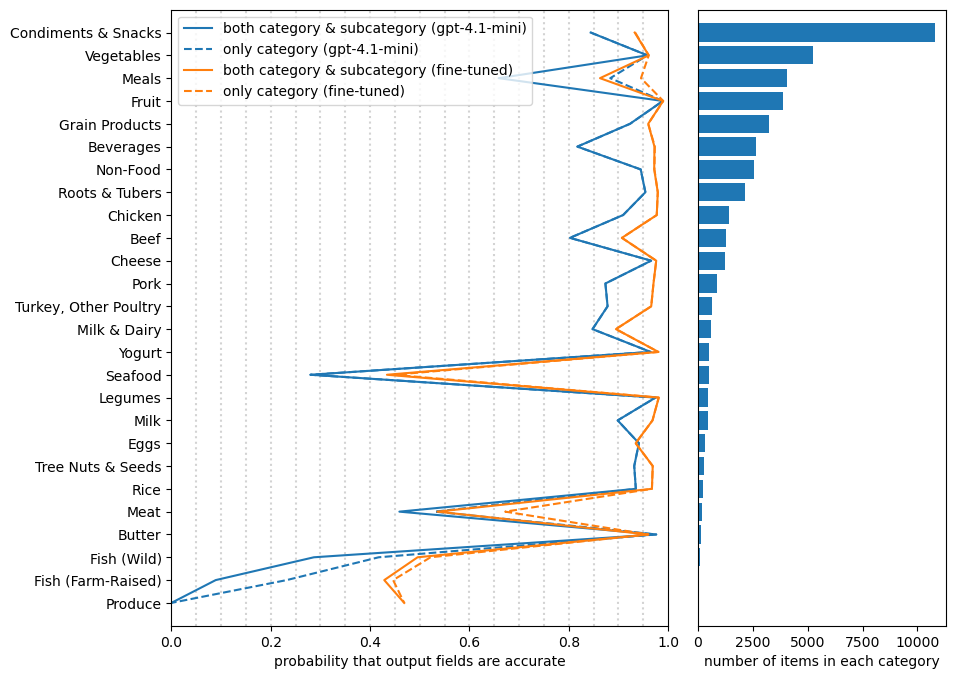

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=[10, 8], gridspec_kw=dict(width_ratios=[2, 1], wspace=0.08))

category_counts = df_category_untuned["category"].value_counts().to_dict()

for level in np.arange(0.05, 1, 0.05):
    ax1.axvline(level, color="lightgrey", ls=":")

fraction1 = []
fraction2 = []
for category, count in category_counts.items():
    df_this_category = df_category_untuned.query(f"category == {category!r}")
    fraction1.append(np.count_nonzero(df_this_category["good_category"]) / len(df_this_category))
    fraction2.append(np.count_nonzero(df_this_category["good_category"] & df_this_category["good_subcategory"]) / len(df_this_category))
ax1.plot(fraction2, range(len(category_counts))[::-1], color="tab:blue", ls="-", label="both category & subcategory (gpt-4.1-mini)")
ax1.plot(fraction1, range(len(category_counts))[::-1], color="tab:blue", ls="--", label="only category (gpt-4.1-mini)")

fraction1 = []
fraction2 = []
for category, count in category_counts.items():
    df_this_category = df_category_finetuned.query(f"category == {category!r}")
    fraction1.append(np.count_nonzero(df_this_category["good_category"]) / len(df_this_category))
    fraction2.append(np.count_nonzero(df_this_category["good_category"] & df_this_category["good_subcategory"]) / len(df_this_category))
ax1.plot(fraction2, range(len(category_counts))[::-1], color="tab:orange", ls="-", label="both category & subcategory (fine-tuned)")
ax1.plot(fraction1, range(len(category_counts))[::-1], color="tab:orange", ls="--", label="only category (fine-tuned)")

ax1.set_yticks(range(len(category_counts)), list(category_counts)[::-1])
ax1.set_xlabel("probability that output fields are accurate")
ax1.set_xlim(0, 1)
ax1.set_ylim(-1, len(category_counts))
ax1.legend(loc="upper left")

ax2.barh(range(len(category_counts)), list(category_counts.values())[::-1])

ax2.set_yticks([])
ax2.set_xlabel("number of items in each category")
ax2.set_ylim(-1, len(category_counts))

None

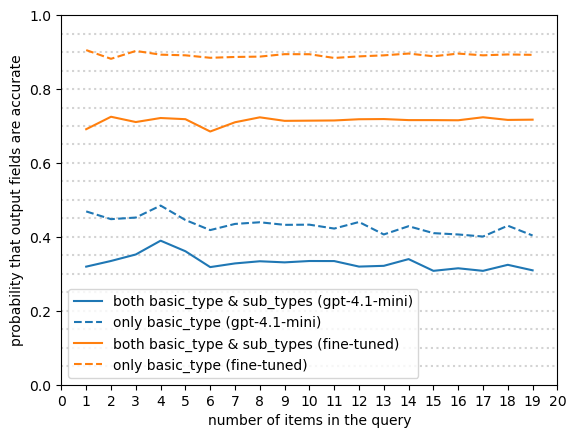

In [11]:
fig, ax = plt.subplots()

for level in np.arange(0.05, 1, 0.05):
    ax.axhline(level, color="lightgrey", ls=":")

fraction1 = []
fraction2 = []
for multiplicity in range(1, 20):
    df_this_multiplicity = df_tag_untuned.query(f"multiplicity == {multiplicity}")
    fraction1.append(np.count_nonzero(df_this_multiplicity["basic_type"]) / len(df_this_multiplicity))
    fraction2.append(np.count_nonzero(df_this_multiplicity["sub_types"]) / len(df_this_multiplicity))
ax.plot(range(1, 20), fraction2, color="tab:blue", ls="-", label="both basic_type & sub_types (gpt-4.1-mini)")
ax.plot(range(1, 20), fraction1, color="tab:blue", ls="--", label="only basic_type (gpt-4.1-mini)")

fraction1 = []
fraction2 = []
for multiplicity in range(1, 20):
    df_this_multiplicity = df_tag_finetuned.query(f"multiplicity == {multiplicity}")
    fraction1.append(np.count_nonzero(df_this_multiplicity["basic_type"]) / len(df_this_multiplicity))
    fraction2.append(np.count_nonzero(df_this_multiplicity["sub_types"]) / len(df_this_multiplicity))
ax.plot(range(1, 20), fraction2, color="tab:orange", ls="-", label="both basic_type & sub_types (fine-tuned)")
ax.plot(range(1, 20), fraction1, color="tab:orange", ls="--", label="only basic_type (fine-tuned)")

ax.set_xlabel("number of items in the query")
ax.set_ylabel("probability that output fields are accurate")
ax.set_xlim(0, 20)
ax.set_xticks(range(21))
ax.set_ylim(0, 1)
ax.legend()

None

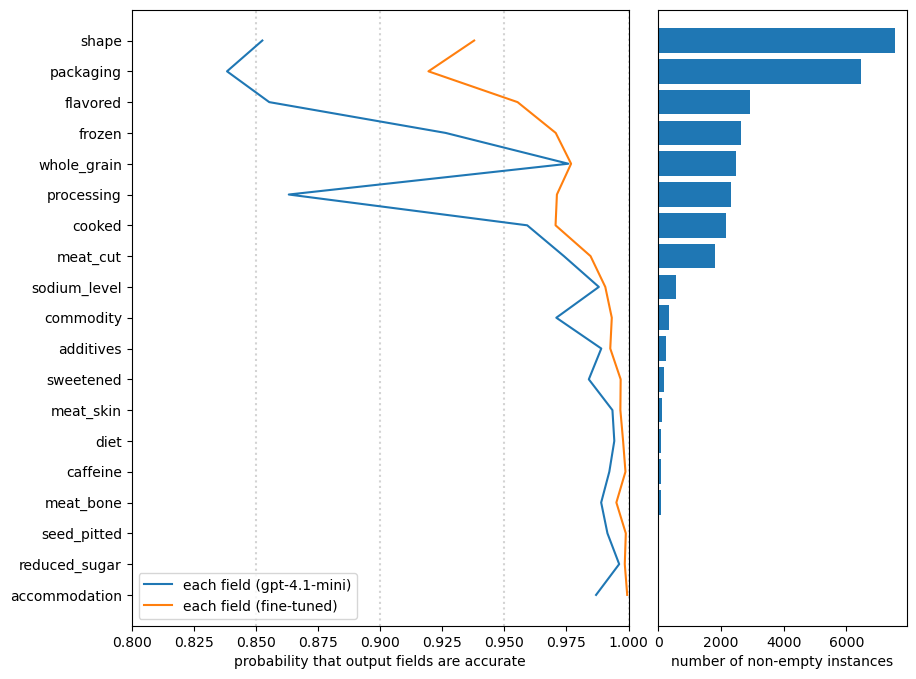

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=[10, 8], gridspec_kw=dict(width_ratios=[2, 1], wspace=0.08))

field_counts = sorted(filled_untuned.items(), key=lambda x: -x[1])

for level in np.arange(0.85, 1, 0.05):
    ax1.axvline(level, color="lightgrey", ls=":")

fraction = []
for field, count in field_counts:
    fraction.append(np.count_nonzero(df_tag_untuned[field]) / len(df_tag_untuned))
ax1.plot(fraction, range(len(field_counts))[::-1], color="tab:blue", ls="-", label="each field (gpt-4.1-mini)")

fraction = []
for field, count in field_counts:
    fraction.append(np.count_nonzero(df_tag_finetuned[field]) / len(df_tag_finetuned))
ax1.plot(fraction, range(len(field_counts))[::-1], color="tab:orange", ls="-", label="each field (fine-tuned)")

ax1.set_yticks(range(len(field_counts)), [name for name, count in field_counts][::-1])
ax1.set_xlabel("probability that output fields are accurate")
ax1.set_xlim(0.8, 1)
ax1.set_ylim(-1, len(field_counts))
ax1.legend(loc="lower left")

ax2.barh(range(len(field_counts)), [count for name, count in field_counts][::-1])

ax2.set_yticks([])
ax2.set_xlabel("number of non-empty instances")
ax2.set_ylim(-1, len(field_counts))

None

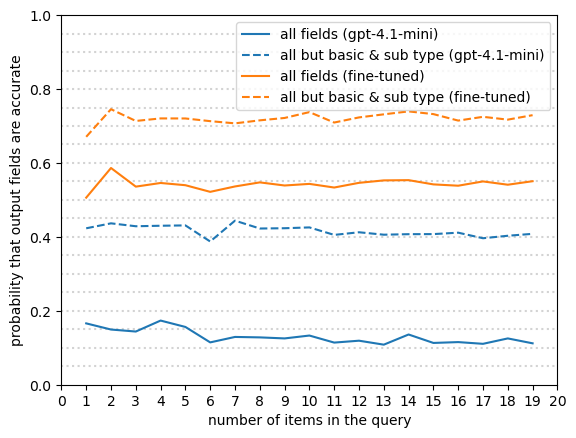

In [13]:
fig, ax = plt.subplots()

for level in np.arange(0.05, 1, 0.05):
    ax.axhline(level, color="lightgrey", ls=":")

fractionall = []
fractionmost = []
for multiplicity in range(1, 20):
    df_this_multiplicity = df_tag_untuned.query(f"multiplicity == {multiplicity}")
    fractionall.append(np.count_nonzero(df_this_multiplicity.iloc[:, 2:].all(axis=1)) / len(df_this_multiplicity))
    fractionmost.append(np.count_nonzero(df_this_multiplicity.iloc[:, 4:].all(axis=1)) / len(df_this_multiplicity))
ax.plot(range(1, 20), fractionall, color="tab:blue", ls="-", label="all fields (gpt-4.1-mini)")
ax.plot(range(1, 20), fractionmost, color="tab:blue", ls="--", label="all but basic & sub type (gpt-4.1-mini)")

fractionall = []
fractionmost = []
for multiplicity in range(1, 20):
    df_this_multiplicity = df_tag_finetuned.query(f"multiplicity == {multiplicity}")
    fractionall.append(np.count_nonzero(df_this_multiplicity.iloc[:, 2:].all(axis=1)) / len(df_this_multiplicity))
    fractionmost.append(np.count_nonzero(df_this_multiplicity.iloc[:, 4:].all(axis=1)) / len(df_this_multiplicity))
ax.plot(range(1, 20), fractionall, color="tab:orange", ls="-", label="all fields (fine-tuned)")
ax.plot(range(1, 20), fractionmost, color="tab:orange", ls="--", label="all but basic & sub type (fine-tuned)")

ax.set_xlabel("number of items in the query")
ax.set_ylabel("probability that output fields are accurate")
ax.set_xlim(0, 20)
ax.set_xticks(range(21))
ax.set_ylim(0, 1)
ax.legend()

None